In [74]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.base import BaseEstimator, TransformerMixin, ClassifierMixin
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.impute import KNNImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier , GradientBoostingClassifier , StackingClassifier , AdaBoostClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score , precision_score , recall_score , f1_score , roc_auc_score , classification_report , confusion_matrix
from sklearn import set_config

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dropout , Dense , Input
from tensorflow.keras import regularizers
from scikeras.wrappers import KerasClassifier

In [75]:
df_train = pd.read_csv('/home/kyburg/kaggle/input/predicting_stellar_class/train.csv')
df_test = pd.read_csv('/home/kyburg/kaggle/input/predicting_stellar_class/test.csv')

In [76]:
df_train.info()

<class 'pandas.DataFrame'>
RangeIndex: 577347 entries, 0 to 577346
Data columns (total 12 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   id                 577347 non-null  int64  
 1   alpha              577347 non-null  float64
 2   delta              577347 non-null  float64
 3   u                  577347 non-null  float64
 4   g                  577347 non-null  float64
 5   r                  577347 non-null  float64
 6   i                  577347 non-null  float64
 7   z                  577347 non-null  float64
 8   redshift           577347 non-null  float64
 9   spectral_type      577347 non-null  str    
 10  galaxy_population  577347 non-null  str    
 11  class              577347 non-null  str    
dtypes: float64(8), int64(1), str(3)
memory usage: 52.9 MB


In [77]:
df_test.info()

<class 'pandas.DataFrame'>
RangeIndex: 247435 entries, 0 to 247434
Data columns (total 11 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   id                 247435 non-null  int64  
 1   alpha              247435 non-null  float64
 2   delta              247435 non-null  float64
 3   u                  247435 non-null  float64
 4   g                  247435 non-null  float64
 5   r                  247435 non-null  float64
 6   i                  247435 non-null  float64
 7   z                  247435 non-null  float64
 8   redshift           247435 non-null  float64
 9   spectral_type      247435 non-null  str    
 10  galaxy_population  247435 non-null  str    
dtypes: float64(8), int64(1), str(2)
memory usage: 20.8 MB


In [78]:
df_train.head()

,id,alpha,delta,u,g,r,i,z,redshift,spectral_type,galaxy_population,class
0,0,147.734256,16.959273,25.472123,21.895559,20.357926,19.257113,18.621057,0.408982,M,Red_Sequence,GALAXY
1,1,127.988677,32.346716,20.778509,19.087062,17.587208,17.226067,16.786433,0.157976,M,Red_Sequence,GALAXY
2,2,179.792648,35.344843,21.035203,21.079128,21.171840,20.582629,20.557366,2.823770,O/B,Blue_Cloud,QSO
3,3,225.818295,48.569421,23.305056,21.050736,19.017754,18.365658,17.914952,0.536099,M,Red_Sequence,GALAXY
4,4,141.836135,19.342852,21.703158,19.471680,18.234449,17.899447,17.616185,0.555761,M,Red_Sequence,GALAXY


In [79]:
def eda(df, subplots_rows, subplots_cols, plot_conf):
    df = df.copy()
    if len(plot_conf) > subplots_rows * subplots_cols:
        print(f'More plot configurations ({len(plot_conf)}) were given than subplots')
        print(f'Using only the first {subplots_rows * subplots_cols} configurations')
        plot_conf = plot_conf[:subplots_rows * subplots_cols]
    fig, axes = plt.subplots(subplots_rows, subplots_cols, figsize=(20, 20))
    for i in range(subplots_rows):
        for j in range(subplots_cols):
            try:
                current_conf = plot_conf[i * subplots_cols + j]
            except:
                continue
            if current_conf['Plot'] == 'pivot_heatmap':
                aggfunc = current_conf['agg_function'] if 'agg_function' in current_conf.keys() else 'sum'
                data = df.pivot_table(
                    values = current_conf['values'],
                    index = current_conf['index'],
                    columns = current_conf['columns'],
                    aggfunc = aggfunc
                )
                annot = current_conf['annot'] if 'annot' in current_conf.keys() else True
                colormap = current_conf['colormap'] if 'colormap' in current_conf.keys() else 'coolwarm'
                sns.heatmap(data, annot=annot, cmap=colormap, ax=axes[i,j])
            elif current_conf['Plot'] == 'boxplot':
                data = [df.dropna()[df[current_conf['columns']] == m][current_conf['values']].values 
                        for m in pd.unique(df[current_conf['columns']].dropna())]
                labels = pd.unique(df[current_conf['columns']].dropna())
                axes[i, j].boxplot(data, tick_labels=labels)
            elif current_conf['Plot'] == 'hist':
                nbins = current_conf['bins'] if 'bins' in current_conf.keys() else 10
                df[current_conf['columns']].hist(bins=nbins, ax=axes[i,j])
            elif current_conf['Plot'] == 'barh':
                aggfunc = current_conf['agg_function'] if 'agg_function' in current_conf.keys() else 'mean'
                data = df.groupby(current_conf['columns'])[current_conf['values']].agg(aggfunc).sort_values(ascending=False)
                colormap = current_conf['colormap'] if 'colormap' in current_conf.keys() else 'steelblue'
                axes[i, j].barh(range(len(data)), data.values, color=colormap)
            elif current_conf['Plot'] == 'corr':
                data = df[current_conf['columns']].corr()
                colormap = current_conf['colormap'] if 'colormap' in current_conf.keys() else 'coolwarm'
                sns.heatmap(data, annot=True, cmap=colormap, ax=axes[i,j])
            elif current_conf['Plot'] == 'scatter':
                if 'values' in current_conf.keys():
                    sns.scatterplot(data=df, x=current_conf['index'], y=current_conf['columns'], hue=current_conf['values'], legend='full', ax=axes[i,j])
                else:
                    sns.scatterplot(data=df, x=current_conf['index'], y=current_conf['columns'], legend='full', ax=axes[i,j])
            elif current_conf['Plot'] == 'discrete_scatter':
                aggfunc = current_conf['agg_function'] if 'agg_function' in current_conf.keys() else 'sum'
                data = df.groupby([current_conf['columns']] + [current_conf['index']], as_index=False)[current_conf['values']].agg(aggfunc)
                sns.scatterplot(data=data, x=current_conf['index'], y=current_conf['columns'], size=current_conf['values'], sizes=(50,500), legend='full', ax=axes[i,j])
            elif current_conf['Plot'] == 'bar':
                df.groupby(current_conf['columns']).size().unstack().plot.bar(ax=axes[i,j])
            elif current_conf['Plot'] == 'kde':
                for m in  pd.unique(df[current_conf['columns']].dropna()):
                    df[df[current_conf['columns']] == m][current_conf['values']].plot.kde(ax=axes[i,j], label=m)
                axes[i,j].legend()
            else:
                print(f"Unrecognized plot: '{current_conf['Plot']}'\n{'-' * 10} Skipping {'-' * 10}")
            if 'title' in current_conf.keys():
                axes[i, j].set_title(current_conf['title'], fontweight='bold')
            if 'set_ylabel' in current_conf.keys():
                axes[i, j].set_ylabel(current_conf['set_ylabel'], fontweight='bold')
            if 'set_xlabel' in current_conf.keys():
                axes[i, j].set_xlabel(current_conf['set_xlabel'], fontweight='bold')
            if 'set_yticks' in current_conf.keys() and current_conf['set_yticks']:
                axes[i, j].set_yticks(range(len(data)))
            if 'set_yticklabels' in current_conf.keys() and current_conf['set_yticklabels']:
                axes[i, j].set_yticklabels(data.index)
            if 'grid' in current_conf.keys():
                axes[i, j].grid(axis=current_conf['grid'][0], alpha=current_conf['grid'][1])

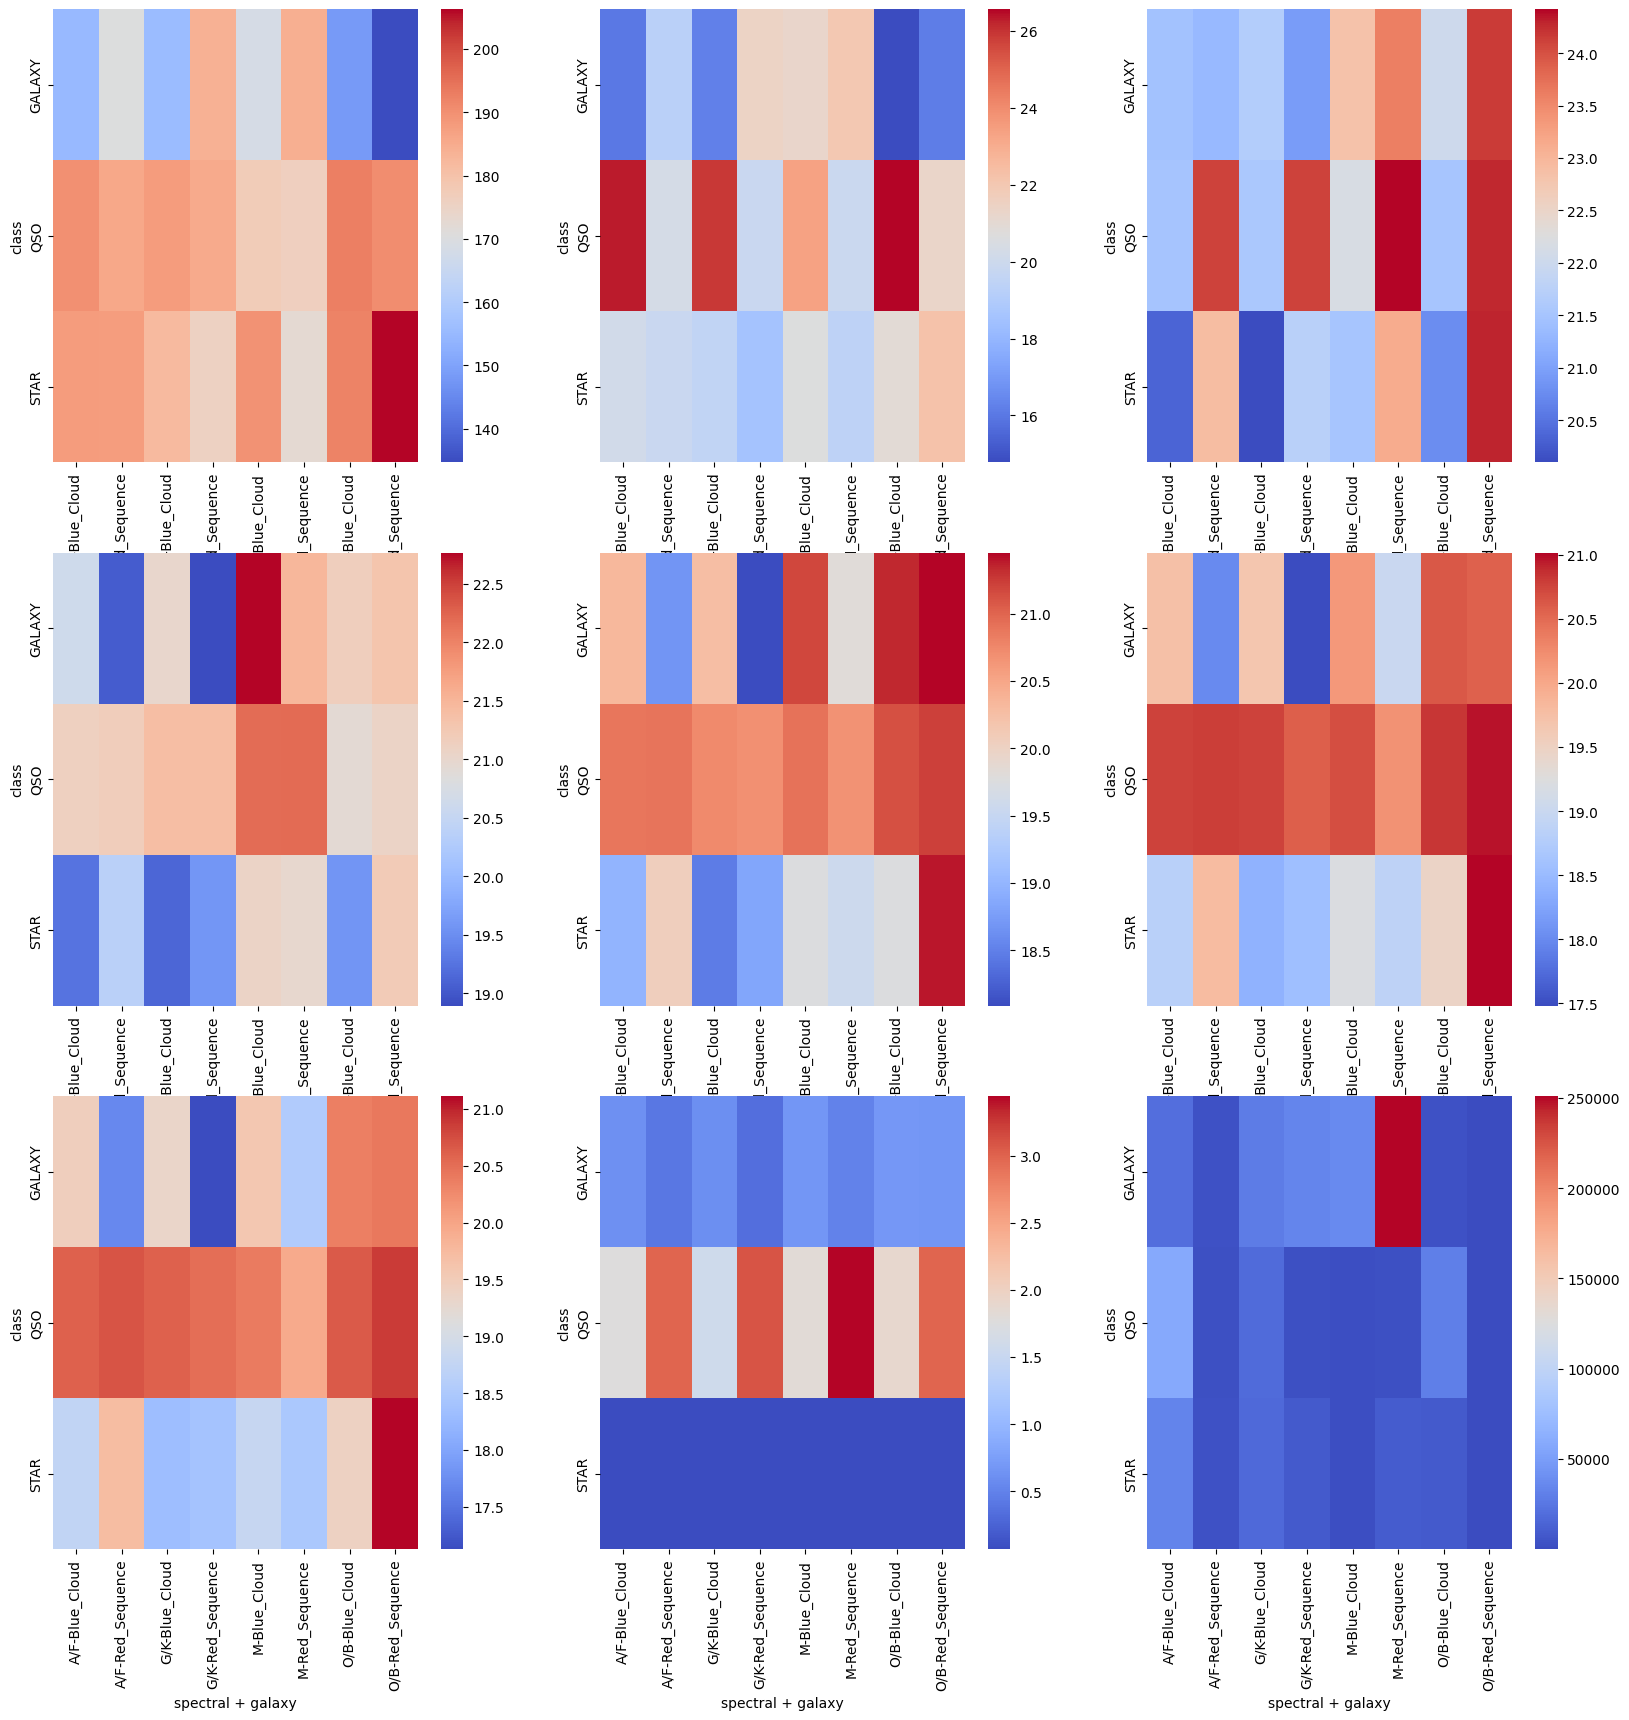

In [80]:
df_eda = df_train.copy()
df_eda['spectral + galaxy'] = df_eda['spectral_type'] + '-' + df_eda['galaxy_population']
eda(df_eda, 3, 3, [
    {'Plot' : 'pivot_heatmap' , 'values' : 'alpha' , 'index' : 'class', 'columns' : 'spectral + galaxy', 'annot' : False, 'agg_function' : 'mean'},
    {'Plot' : 'pivot_heatmap' , 'values' : 'delta' , 'index' : 'class', 'columns' : 'spectral + galaxy', 'annot' : False, 'agg_function' : 'mean'},
    {'Plot' : 'pivot_heatmap' , 'values' : 'u' , 'index' : 'class', 'columns' : 'spectral + galaxy', 'annot' : False, 'agg_function' : 'mean'},
    {'Plot' : 'pivot_heatmap' , 'values' : 'g' , 'index' : 'class', 'columns' : 'spectral + galaxy', 'annot' : False, 'agg_function' : 'mean'},
    {'Plot' : 'pivot_heatmap' , 'values' : 'r' , 'index' : 'class', 'columns' : 'spectral + galaxy', 'annot' : False, 'agg_function' : 'mean'},
    {'Plot' : 'pivot_heatmap' , 'values' : 'i' , 'index' : 'class', 'columns' : 'spectral + galaxy', 'annot' : False, 'agg_function' : 'mean'},
    {'Plot' : 'pivot_heatmap' , 'values' : 'z' , 'index' : 'class', 'columns' : 'spectral + galaxy', 'annot' : False, 'agg_function' : 'mean'},
    {'Plot' : 'pivot_heatmap' , 'values' : 'redshift' , 'index' : 'class', 'columns' : 'spectral + galaxy', 'annot' : False, 'agg_function' : 'mean'},
    {'Plot' : 'pivot_heatmap' , 'values' : 'id' , 'index' : 'class', 'columns' : 'spectral + galaxy', 'annot' : False, 'agg_function' : 'count'}
])

In [81]:
df_eda.groupby(['class', 'spectral_type', 'galaxy_population'])['id'].count()

class   spectral_type  galaxy_population
GALAXY  A/F            Blue_Cloud            20316
                       Red_Sequence           3924
        G/K            Blue_Cloud            28115
                       Red_Sequence          33512
        M              Blue_Cloud            37062
                       Red_Sequence         250961
        O/B            Blue_Cloud             3469
                       Red_Sequence            121
QSO     A/F            Blue_Cloud            58454
                       Red_Sequence           3060
        G/K            Blue_Cloud            18154
                       Red_Sequence           2767
        M              Blue_Cloud             1447
                       Red_Sequence           2442
        O/B            Blue_Cloud            30219
                       Red_Sequence            600
STAR    A/F            Blue_Cloud            32772
                       Red_Sequence           3596
        G/K            Blue_Cloud        

In [82]:
df_train['spectral_type'].nunique()

4

In [83]:
df_train['class'].nunique()

3

In [84]:
df_train['galaxy_population'].nunique()

2

In [85]:
cat_cols = ['galaxy_population' , 'spectral_type']
if 'id' in df_train.columns:
    df_train.drop(columns='id', inplace=True)
X = df_train.drop(columns='class')
y = df_train['class'].copy()
scaler = StandardScaler()
X[X.columns.difference(cat_cols)] = scaler.fit_transform(X[X.columns.difference(cat_cols)])
X = pd.get_dummies(X)
le = LabelEncoder()
y = pd.DataFrame({'class' : le.fit_transform(y)})
X.info()

<class 'pandas.DataFrame'>
RangeIndex: 577347 entries, 0 to 577346
Data columns (total 14 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   alpha                           577347 non-null  float64
 1   delta                           577347 non-null  float64
 2   u                               577347 non-null  float64
 3   g                               577347 non-null  float64
 4   r                               577347 non-null  float64
 5   i                               577347 non-null  float64
 6   z                               577347 non-null  float64
 7   redshift                        577347 non-null  float64
 8   spectral_type_A/F               577347 non-null  bool   
 9   spectral_type_G/K               577347 non-null  bool   
 10  spectral_type_M                 577347 non-null  bool   
 11  spectral_type_O/B               577347 non-null  bool   
 12  galaxy_population_Blue_Clou

In [86]:
y.info()

<class 'pandas.DataFrame'>
RangeIndex: 577347 entries, 0 to 577346
Data columns (total 1 columns):
 #   Column  Non-Null Count   Dtype
---  ------  --------------   -----
 0   class   577347 non-null  int64
dtypes: int64(1)
memory usage: 4.4 MB


In [ ]:
class NN_Multiclass_Model(BaseEstimator, ClassifierMixin):
    def __init__(self, geometry, l1, l2):
        self.geometry = geometry
        self.l1 = l1
        self.l2 = l2
        self.model = Sequential()
        self.model.add(Input(shape=(geometry[0],)))
        self.model.add(Dense(units=geometry[1], activation="relu", kernel_regularizer=regularizers.l1_l2(l1=l1, l2=l2)))
        self.model.add(Dropout(0.3))
        self.model.add(Dense(units=geometry[2], activation="relu", kernel_regularizer=regularizers.l1_l2(l1=l1, l2=l2)))
        self.model.add(Dropout(0.2))
        self.model.add(Dense(units=geometry[3], activation="relu", kernel_regularizer=regularizers.l1_l2(l1=l1, l2=l2)))
        self.model.add(Dropout(0.2))
        self.model.add(Dense(units=geometry[4], activation="sigmoid"))
        self.model.compile(optimizer="adam" , loss="binary_crossentropy" , metrics=["accuracy"])
        self.ohe = OneHotEncoder(sparse_output=False)
    def fit(self, X, y):
        try:
            y = self.ohe.fit_transform(y.reshape(-1,1))
        except:
            y = self.ohe.fit_transform(y)
        self.model.fit(X, y , epochs=25 , batch_size = 32 , verbose = 1)
        return self
    def predict(self, X):
        return self.model.predict(X).argmax(axis=1)

In [88]:
def get_models(nn_shape):
    return {
        'Logistic Regression': LogisticRegression(
            max_iter=1000, class_weight='balanced', random_state=42,
            solver='lbfgs'
        ),
        'Random Forest': RandomForestClassifier(
            n_estimators=100, max_depth=15, min_samples_split=5,
            random_state=42, n_jobs=-1, class_weight='balanced'
        ),
        'XGBoost': XGBClassifier(
            n_estimators=100, max_depth=6, learning_rate=0.1,
            subsample=0.8, colsample_bytree=0.8, random_state=42,
            n_jobs=-1, eval_metric='logloss', verbosity=0
        ),
        'LightGBM': LGBMClassifier(
            n_estimators=100, max_depth=7, learning_rate=0.1,
            subsample=0.8, colsample_bytree=0.8, random_state=42,
            n_jobs=-1, verbose=-1
        ),
        'KNN' : KNeighborsClassifier(n_neighbors=3),
        'AdaBoost' : AdaBoostClassifier(
            n_estimators=100, random_state=42, learning_rate=0.1
        ),
        'NN1' : NN_Multiclass_Model([nn_shape, 16, 12, 6, 3], 1e-4, 1e-3),
        'NN2' : NN_Multiclass_Model([nn_shape, 8, 6, 4, 3], 1e-4, 1e-3)
    }

In [89]:
classifiers = get_models(X.shape[1])
X_tr, X_val, y_tr, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
ohe = OneHotEncoder(sparse_output=False)
y_tr_dummy = pd.get_dummies(y_tr)
y_val_dummy = ohe.fit_transform(y_val.to_numpy().reshape(-1,1)).astype(int)
for clf_name, clf in classifiers.items():
    if clf_name == 'NN1' or clf_name == 'NN2':
        clf.fit(X_tr, y_tr)
    else:
        clf.fit(X_tr, y_tr.values.ravel())
    y_pred = clf.predict(X_val)
    if hasattr(clf, 'predict_proba'):
        y_pred_proba = clf.predict_proba(X_val)
    elif hasattr(clf, 'decision_function'):
        y_pred_proba = clf.decision_function(X_val)
    else:
        y_pred_proba = None
    accuracy = accuracy_score(y_val, y_pred)
    y_pred_ohe = ohe.transform(y_pred.reshape(-1,1)).astype(int)
    f1 = f1_score(y_val_dummy, y_pred_ohe, zero_division=0, average=None)
    if y_pred_proba is not None:
        roc_auc = roc_auc_score(y_val_dummy, y_pred_proba,  multi_class='ovo')
    else:
        roc_auc = 0.0
    print(f'  {clf_name:20} | Acc: {accuracy:.4f} | F1: {f1} | ROC AUC: {roc_auc:.4f}')

  Logistic Regression  | Acc: 0.8896 | F1: [0.91877759 0.89966788 0.77325377] | ROC AUC: 0.9806
  Random Forest        | Acc: 0.9506 | F1: [0.96437048 0.95559585 0.88559418] | ROC AUC: 0.9933
  XGBoost              | Acc: 0.9601 | F1: [0.97232872 0.96020572 0.90402739] | ROC AUC: 0.9948
  LightGBM             | Acc: 0.9627 | F1: [0.97372075 0.96327212 0.91120136] | ROC AUC: 0.9954
  KNN                  | Acc: 0.9465 | F1: [0.96470108 0.94562057 0.86373908] | ROC AUC: 0.9712
  AdaBoost             | Acc: 0.8730 | F1: [0.90987896 0.82450818 0.78087564] | ROC AUC: 0.9640
Epoch 1/25
57735/57735 ━━━━━━━━━━━━━━━━━━━━ 68s 1ms/step - accuracy: 0.8952 - loss: 0.2206
Epoch 2/25
57735/57735 ━━━━━━━━━━━━━━━━━━━━ 68s 1ms/step - accuracy: 0.9061 - loss: 0.1973
Epoch 3/25
57735/57735 ━━━━━━━━━━━━━━━━━━━━ 66s 1ms/step - accuracy: 0.9064 - loss: 0.1938
Epoch 4/25
57735/57735 ━━━━━━━━━━━━━━━━━━━━ 68s 1ms/step - accuracy: 0.9063 - loss: 0.1921
Epoch 5/25
57735/57735 ━━━━━━━━━━━━━━━━━━━━ 66s 1ms/step - a

In [90]:
top_classifiers = ['Random Forest', 'XGBoost', 'LightGBM', 'NN1', 'NN2', 'Logistic Regression']
ensemble_dict = {}
classifiers = get_models(nn_shape = X.shape[1])
for name in top_classifiers:
    clf = classifiers[name]
    ensemble_dict[name] = clf
    print(f'✔ {name} trained')
ensemble = StackingClassifier(
    estimators=[(name, ensemble_dict[name]) for name in top_classifiers],
)
ensemble.fit(X, y)
ensemble_train_score = ensemble.score(X, y)
print(f'✔ Ensemble training accuracy: {ensemble_train_score:.4f}')

✔ Random Forest trained
✔ XGBoost trained
✔ LightGBM trained
✔ NN1 trained
✔ NN2 trained
✔ Logistic Regression trained


/home/kyburg/Code/Python/ML_env_312/lib/python3.12/site-packages/sklearn/preprocessing/_label.py:103: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/home/kyburg/Code/Python/ML_env_312/lib/python3.12/site-packages/sklearn/preprocessing/_label.py:139: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, dtype=self.classes_.dtype, warn=True)


Epoch 1/25
72169/72169 ━━━━━━━━━━━━━━━━━━━━ 82s 1ms/step - accuracy: 0.8902 - loss: 0.2161
Epoch 2/25
72169/72169 ━━━━━━━━━━━━━━━━━━━━ 78s 1ms/step - accuracy: 0.9067 - loss: 0.1956
Epoch 3/25
72169/72169 ━━━━━━━━━━━━━━━━━━━━ 78s 1ms/step - accuracy: 0.9069 - loss: 0.1924
Epoch 4/25
72169/72169 ━━━━━━━━━━━━━━━━━━━━ 76s 1ms/step - accuracy: 0.9073 - loss: 0.1905
Epoch 5/25
72169/72169 ━━━━━━━━━━━━━━━━━━━━ 83s 1ms/step - accuracy: 0.9081 - loss: 0.1893
Epoch 6/25
72169/72169 ━━━━━━━━━━━━━━━━━━━━ 80s 1ms/step - accuracy: 0.9076 - loss: 0.1887
Epoch 7/25
72169/72169 ━━━━━━━━━━━━━━━━━━━━ 81s 1ms/step - accuracy: 0.9090 - loss: 0.1880
Epoch 8/25
72169/72169 ━━━━━━━━━━━━━━━━━━━━ 83s 1ms/step - accuracy: 0.9090 - loss: 0.1883
Epoch 9/25
72169/72169 ━━━━━━━━━━━━━━━━━━━━ 76s 1ms/step - accuracy: 0.9095 - loss: 0.1871
Epoch 10/25
72169/72169 ━━━━━━━━━━━━━━━━━━━━ 81s 1ms/step - accuracy: 0.9083 - loss: 0.1876
Epoch 11/25
72169/72169 ━━━━━━━━━━━━━━━━━━━━ 84s 1ms/step - accuracy: 0.9084 - loss: 0.18

In [91]:
X_test = df_test.drop(columns='id')
scaler = StandardScaler()
X_test[X_test.columns.difference(cat_cols)] = scaler.fit_transform(X_test[X_test.columns.difference(cat_cols)])
X_test = pd.get_dummies(X_test)
y_pred_test = ensemble.predict(X_test)
y_pred_test = le.inverse_transform(y_pred_test)
submission = pd.DataFrame({
    'id' : df_test['id'],
    'Class' : y_pred_test
})
submission.to_csv('submission.csv', index=False)

7733/7733 ━━━━━━━━━━━━━━━━━━━━ 4s 451us/step
7733/7733 ━━━━━━━━━━━━━━━━━━━━ 3s 431us/step
